*f(R) Gravity Analysis with MCMC
Complete pipeline for analyzing modified gravity using galaxy and CMB cross-correlation*

- Author: Adrita Khan
- Date: 27-11-2025

This code performs:
1. Computation of angular power spectra for f(R) gravity models
2. Generation of mock observational data
3. Bayesian parameter inference via MCMC sampling
4. Statistical analysis and visualization of constraints

In [15]:
# ========================================================
# Installation (run once)
# ========================================================
# !pip install -q baccoemu emantis scipy astropy pyccl pocomc emcee getdist corner

In [16]:
# ==============================================================================
# SECTION 1: ENVIRONMENT SETUP AND IMPORTS
# ==============================================================================

import os
import sys
import warnings
import logging
from contextlib import redirect_stdout, redirect_stderr

# Suppress TensorFlow warnings and logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Configure warning filters
warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)
logging.getLogger("tensorflow").setLevel(logging.CRITICAL)

# Import scientific computing libraries
print("Loading scientific libraries...")
with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull), redirect_stderr(fnull):
        import numpy as np
        import matplotlib.pyplot as plt
        import baccoemu
        import astropy
        from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
        import pyccl as ccl
        from scipy.interpolate import interp1d
        from scipy.integrate import quad, simpson
        import emcee
        import corner

print("✓ Libraries loaded successfully\n")

Loading scientific libraries...
✓ Libraries loaded successfully



In [17]:
# =====================================================================
# Cosmological Parameters
# =====================================================================
common_params = {
    "Omega_m": 0.315,
    "Omega_b": 0.05,
    "h": 0.67,
    "n_s": 0.96,
    "A_s": 2.215e-9,
    "M_nu": 0.0,
    "w0": -1.0,
    "wa": 0.0,
    "aexp": 1.0
}

In [18]:
# =====================================================================
# Bacco Emulator Setup
# =====================================================================
print("Initializing Bacco emulator...")
with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull):
        emulator = baccoemu.Matter_powerspectrum(verbose=False)
        k = np.logspace(-2, np.log10(emulator.emulator['nonlinear']['k'].max()), num=200)

        params_bacco = {
            "omega_cold": common_params["Omega_m"] - common_params["Omega_b"],
            "A_s": common_params["A_s"],
            "omega_baryon": common_params["Omega_b"],
            "ns": common_params["n_s"],
            "hubble": common_params["h"],
            "neutrino_mass": common_params["M_nu"],
            "w0": common_params["w0"],
            "wa": common_params["wa"],
            "expfactor": common_params["aexp"]
        }

        k, Q_total = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
        k, pk_nl_total = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)

print(f"Bacco power spectrum computed at {len(k)} k-points")

Initializing Bacco emulator...
Bacco power spectrum computed at 200 k-points


In [19]:
# =====================================================================
# CCL Cosmology Setup
# =====================================================================
print("Setting up CCL cosmology...")
cosmo = ccl.Cosmology(
    Omega_c=common_params["Omega_m"] - common_params["Omega_b"],
    Omega_b=common_params["Omega_b"],
    h=common_params["h"],
    n_s=common_params["n_s"],
    A_s=common_params["A_s"],
    w0=common_params["w0"],
    wa=common_params["wa"],
    m_nu=common_params["M_nu"],
    transfer_function='boltzmann_camb'
)

Setting up CCL cosmology...


In [20]:
# =====================================================================
# Galaxy Distribution & Bias Model
# =====================================================================
z_grid = np.linspace(0.01, 3.0, 500)
dNdz_raw = np.exp(-z_grid / 0.3)
dNdz = dNdz_raw / np.trapz(dNdz_raw, z_grid)

b0 = 2.0
bias_array = np.ones_like(z_grid) * b0

In [21]:
# =====================================================================
# CCL Tracers (Galaxy & CMB Lensing)
# =====================================================================
print("CCL tracers")
galaxy_tracer = ccl.NumberCountsTracer(
    cosmo,
    has_rsd=False,
    dndz=(z_grid, dNdz),
    bias=(z_grid, bias_array)
)

cmb_tracer = ccl.CMBLensingTracer(cosmo, z_source=1100.0)

CCL tracers


In [22]:
# =====================================================================
#  Function: Compute Cℓ with Custom P(k)
# =====================================================================
def compute_Cl_with_pk(pk_array, k, ell_array, cosmo, galaxy_tracer, cmb_tracer):
    """
    Compute C_ell using a custom power spectrum.
    Returns: Cl_gg, Cl_kg
    """
    z_pk = np.array([3.0, 2.0, 1.0, 0.5, 0.0])
    a_arr = 1.0 / (1.0 + z_pk)

    D_z = np.array([ccl.growth_factor(cosmo, a) for a in a_arr])
    D_ratio_sq = (D_z / D_z[-1])**2

    pk_2d_arr = np.outer(D_ratio_sq, pk_array)

    lk_arr = np.log(k)
    log_pk_2d_arr = np.log(pk_2d_arr + 1e-30)

    pk2d = ccl.Pk2D(
        a_arr=a_arr,
        lk_arr=lk_arr,
        pk_arr=log_pk_2d_arr,
        is_logp=True,
        extrap_order_lok=1,
        extrap_order_hik=1
    )

    Cl_gg = ccl.angular_cl(cosmo, galaxy_tracer, galaxy_tracer, ell_array, p_of_k_a=pk2d)
    Cl_kg = ccl.angular_cl(cosmo, cmb_tracer, galaxy_tracer, ell_array, p_of_k_a=pk2d)

    return Cl_gg, Cl_kg

In [23]:
# =====================================================================
# Compute Cℓ for GR (Baseline)
# =====================================================================
print("C_ell for GR")
ell = np.logspace(np.log10(10), np.log10(2000), 50)

Cl_gg_gr, Cl_kg_gr = compute_Cl_with_pk(
    pk_nl_total, k, ell, cosmo, galaxy_tracer, cmb_tracer
)

C_ell for GR


In [24]:
# =====================================================================
# Compute Cℓ for f(R) Gravity Models
# =====================================================================
fR_values_to_plot = [4, 5, 6]
Cl_gg_dict = {None: Cl_gg_gr}
Cl_kg_dict = {None: Cl_kg_gr}

print("C_ell for f(R) models...")
emu = NonLinearMGBoostEmulator(verbose=False)

for logfR0_val in fR_values_to_plot:
    print(f" For logfR0 = {logfR0_val}...")

    params_emantis = {
        "Omega_m": common_params["Omega_m"],
        "Omega_b": common_params["Omega_b"],
        "h": common_params["h"],
        "n_s": common_params["n_s"],
        "A_s": common_params["A_s"],
        "logfR0": logfR0_val
    }

    pk_boost = emu.predict_boost(params_emantis, aexp=common_params["aexp"], k=k)
    pk_fR = pk_nl_total * pk_boost

    Cl_gg_fr, Cl_kg_fr = compute_Cl_with_pk(
        pk_fR, k, ell, cosmo, galaxy_tracer, cmb_tracer
    )

    Cl_gg_dict[logfR0_val] = Cl_gg_fr
    Cl_kg_dict[logfR0_val] = Cl_kg_fr

C_ell for f(R) models...
 For logfR0 = 4...
 For logfR0 = 5...
 For logfR0 = 6...


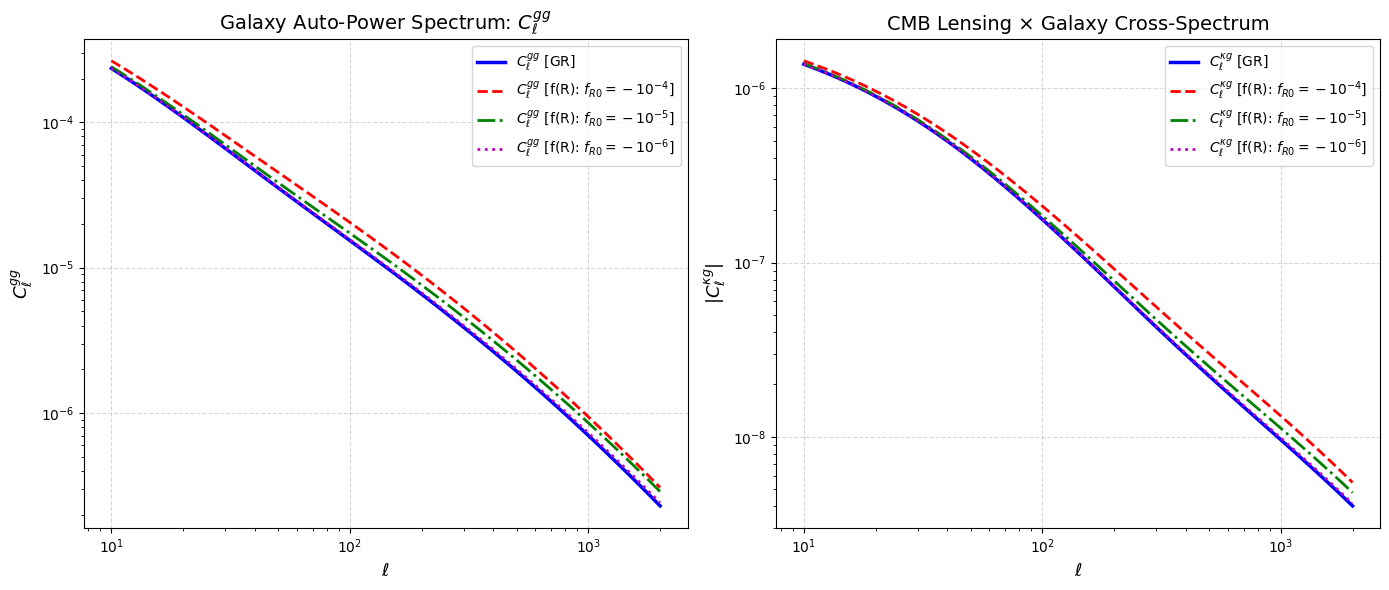

In [25]:
# =====================================================================
# Plotting Cℓ Spectra
# =====================================================================
plt.figure(figsize=(14, 6))

# --- GG Auto ---
plt.subplot(1, 2, 1)
plt.loglog(ell, Cl_gg_gr, 'b-', linewidth=2.5, label=r'$C_\ell^{gg}$ [GR]')

colors = ['r', 'g', 'm']
line_styles = ['--', '-.', ':']

for i, logfR0_val in enumerate(fR_values_to_plot):
    plt.loglog(
        ell,
        Cl_gg_dict[logfR0_val],
        color=colors[i],
        linestyle=line_styles[i],
        linewidth=2,
        label=rf'$C_\ell^{{gg}}$ [f(R): $f_{{R0}}=-10^{{-{logfR0_val}}}$]'
    )

plt.xlabel(r'$\ell$', fontsize=13)
plt.ylabel(r'$C_\ell^{gg}$', fontsize=13)
plt.title(r'Galaxy Auto-Power Spectrum: $C_\ell^{gg}$', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, ls='--', alpha=0.5)

# --- KG Cross ---
plt.subplot(1, 2, 2)
plt.loglog(ell, np.abs(Cl_kg_gr), 'b-', linewidth=2.5, label=r'$C_\ell^{\kappa g}$ [GR]')

for i, logfR0_val in enumerate(fR_values_to_plot):
    plt.loglog(
        ell,
        np.abs(Cl_kg_dict[logfR0_val]),
        color=colors[i],
        linestyle=line_styles[i],
        linewidth=2,
        label=rf'$C_\ell^{{\kappa g}}$ [f(R): $f_{{R0}}=-10^{{-{logfR0_val}}}$]'
    )

plt.xlabel(r'$\ell$', fontsize=13)
plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=13)
plt.title(r'CMB Lensing × Galaxy Cross-Spectrum', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Cl_comparison.png', dpi=150)
plt.show()

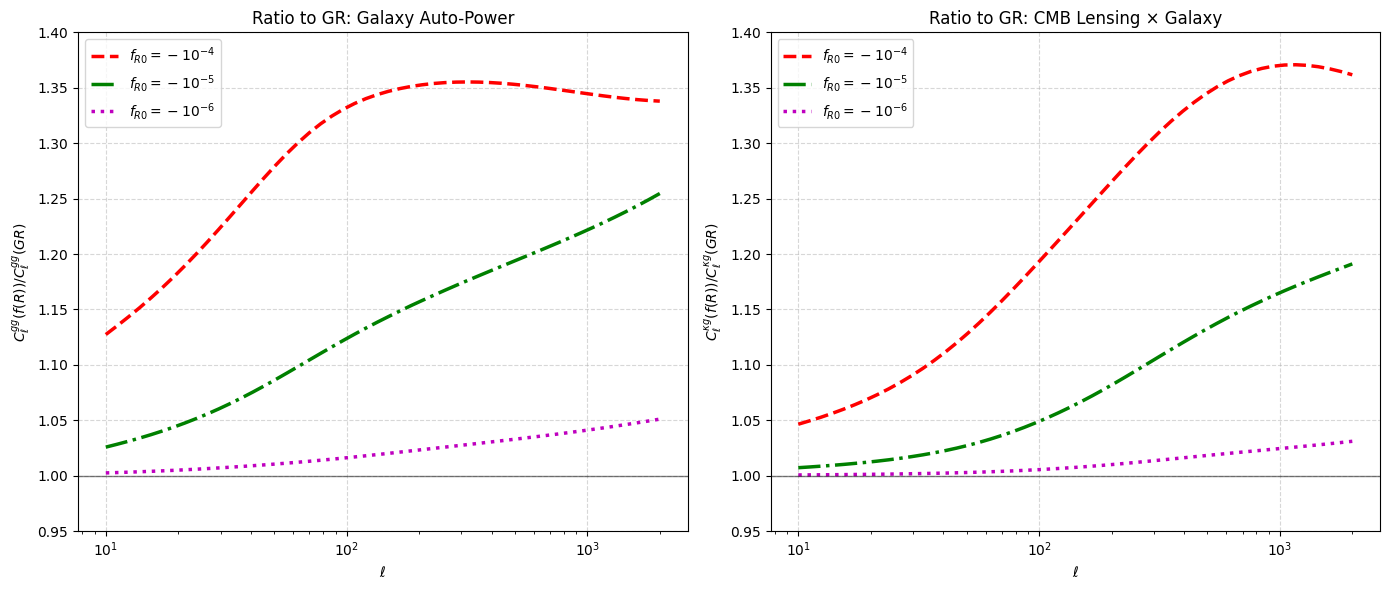

In [26]:
# =====================================================================
# Ratio-to-GR Plots
# =====================================================================
plt.figure(figsize=(14, 6))

# --- GG Ratio ---
plt.subplot(1, 2, 1)
for i, logfR0_val in enumerate(fR_values_to_plot):
    ratio = Cl_gg_dict[logfR0_val] / Cl_gg_dict[None]
    plt.semilogx(ell, ratio, color=colors[i], linestyle=line_styles[i],
                 linewidth=2.5, label=rf'$f_{{R0}} = -10^{{-{logfR0_val}}}$')

plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{gg}(f(R)) / C_\ell^{gg}(GR)$')
plt.title("Ratio to GR: Galaxy Auto-Power")
plt.grid(True, ls='--', alpha=0.5)
plt.ylim([0.95, 1.4])
plt.legend()

# --- KG Ratio ---
plt.subplot(1, 2, 2)
for i, logfR0_val in enumerate(fR_values_to_plot):
    ratio = Cl_kg_dict[logfR0_val] / Cl_kg_dict[None]
    plt.semilogx(ell, ratio, color=colors[i], linestyle=line_styles[i],
                 linewidth=2.5, label=rf'$f_{{R0}} = -10^{{-{logfR0_val}}}$')

plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{\kappa g}(f(R)) / C_\ell^{\kappa g}(GR)$')
plt.title("Ratio to GR: CMB Lensing × Galaxy")
plt.grid(True, ls='--', alpha=0.5)
plt.ylim([0.95, 1.4])
plt.legend()

plt.tight_layout()
plt.savefig('Cl_ratio_to_GR.png', dpi=150)
plt.show()

In [27]:
# =====================================================================
# Generate Mock Data
# =====================================================================
print("\n" + "="*60)
print("GENERATING MOCK DATA")
print("="*60)

true_logfR0 = 5
Cl_gg_true = Cl_gg_dict[true_logfR0]
Cl_kg_true = Cl_kg_dict[true_logfR0]

np.random.seed(42)
noise_level_gg = 0.05
noise_level_kg = 0.08

Cl_gg_obs = Cl_gg_true * (1 + np.random.normal(0, noise_level_gg, len(ell)))
Cl_kg_obs = Cl_kg_true * (1 + np.random.normal(0, noise_level_kg, len(ell)))

sigma_gg = noise_level_gg * Cl_gg_true
sigma_kg = noise_level_kg * np.abs(Cl_kg_true)

C_kk_fid = ccl.angular_cl(cosmo, cmb_tracer, cmb_tracer, ell)

f_sky = 0.4
cov_gg_diag = 2.0 * Cl_gg_true**2 / ((2 * ell + 1) * f_sky) + sigma_gg**2
cov_kg_diag = (Cl_kg_true**2 + C_kk_fid * Cl_gg_true) / ((2 * ell + 1) * f_sky) + sigma_kg**2

mask_gg = (
    np.isfinite(Cl_gg_obs) &
    np.isfinite(cov_gg_diag) &
    (cov_gg_diag > 0) &
    (Cl_gg_obs > 0)
)

mask_kg = (
    np.isfinite(Cl_kg_obs) &
    np.isfinite(cov_kg_diag) &
    (cov_kg_diag > 0) &
    (np.abs(Cl_kg_obs) > 1e-15)
)

ell_gg = ell[mask_gg]
C_gg_data = Cl_gg_obs[mask_gg]
inv_cov_gg = np.diag(1.0 / cov_gg_diag[mask_gg])

ell_kg = ell[mask_kg]
C_kg_data = Cl_kg_obs[mask_kg]
inv_cov_kg = np.diag(1.0 / cov_kg_diag[mask_kg])

print(f"Mock data generated:")
print(f"  Galaxy auto: {len(C_gg_data)} points")
print(f"  Galaxy-CMB: {len(C_kg_data)} points")


GENERATING MOCK DATA
Mock data generated:
  Galaxy auto: 50 points
  Galaxy-CMB: 50 points


In [28]:
# =====================================================================
# Fiducial Parameters for MCMC
# =====================================================================
fiducial_params = {
    'Omega_m': 0.315,
    'Omega_b': 0.05,
    'h': 0.67,
    'n_s': 0.96,
    'A_s': 2.215e-9,
    'b0': 2.0,
    'logfR0': 5.0
}

In [29]:
# =====================================================================
# Prior, Likelihood & Posterior Functions
# =====================================================================
def log_prior(params):
    """
    Log-prior for parameters (uniform within bounds).
    Parameters: [Omega_m, h, A_s, b0, logfR0]
    """
    Omega_m, h, A_s, b0, logfR0 = params

    if not (0.2 < Omega_m < 0.5): return -np.inf
    if not (0.5 < h < 0.9): return -np.inf
    if not (1e-10 < A_s < 1e-8): return -np.inf
    if not (1.0 < b0 < 3.0): return -np.inf
    if not (4.0 <= logfR0 <= 6.0): return -np.inf

    return 0.0  # Uniform prior


def log_likelihood_mcmc(params, use_cross_spectrum=True):
    """
    Log-likelihood for MCMC sampling.
    Parameters: [Omega_m, h, A_s, b0, logfR0]
    """
    try:
        Omega_m, h, A_s, b0, logfR0 = params

        # Reject out-of-range
        if not (0.2 < Omega_m < 0.5): return -np.inf
        if not (0.5 < h < 0.9): return -np.inf
        if not (1e-10 < A_s < 1e-8): return -np.inf
        if not (1.0 < b0 < 3.0): return -np.inf
        if not (4.0 <= logfR0 <= 6.0): return -np.inf

        Omega_b = 0.05
        n_s = 0.96

        # Temporary cosmology
        cosmo_temp = ccl.Cosmology(
            Omega_c=Omega_m - Omega_b,
            Omega_b=Omega_b,
            h=h,
            n_s=n_s,
            A_s=A_s,
            w0=-1.0,
            wa=0.0,
            m_nu=0.0,
            transfer_function='boltzmann_camb'
        )

        # Update tracers
        bias_array_temp = np.ones_like(z_grid) * b0

        galaxy_tracer_temp = ccl.NumberCountsTracer(
            cosmo_temp,
            has_rsd=False,
            dndz=(z_grid, dNdz),
            bias=(z_grid, bias_array_temp)
        )
        cmb_tracer_temp = ccl.CMBLensingTracer(cosmo_temp, z_source=1100.0)

        # Compute P(k)
        params_bacco_temp = {
            "omega_cold": Omega_m - Omega_b,
            "A_s": A_s,
            "omega_baryon": Omega_b,
            "ns": n_s,
            "hubble": h,
            "neutrino_mass": 0.0,
            "w0": -1.0,
            "wa": 0.0,
            "expfactor": 1.0
        }

        with open(os.devnull, 'w') as fnull:
            with redirect_stdout(fnull):
                _, pk_nl_temp = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco_temp)

        # Apply f(R)
        params_emantis_temp = {
            "Omega_m": Omega_m,
            "Omega_b": Omega_b,
            "h": h,
            "n_s": n_s,
            "A_s": A_s,
            "logfR0": logfR0
        }

        pk_boost_temp = emu.predict_boost(params_emantis_temp, aexp=1.0, k=k)
        pk_fR_temp = pk_nl_temp * pk_boost_temp

        Cl_gg_model_full, Cl_kg_model_full = compute_Cl_with_pk(
            pk_fR_temp, k, ell, cosmo_temp, galaxy_tracer_temp, cmb_tracer_temp
        )

        Cl_gg_model = Cl_gg_model_full[mask_gg]
        Cl_kg_model = Cl_kg_model_full[mask_kg]

        chi2 = 0.0
        diff_gg = Cl_gg_model - C_gg_data
        chi2 += np.dot(diff_gg, np.dot(inv_cov_gg, diff_gg))

        if use_cross_spectrum:
            diff_kg = Cl_kg_model - C_kg_data
            chi2 += np.dot(diff_kg, np.dot(inv_cov_kg, diff_kg))

        return -0.5 * chi2

    except Exception:
        return -np.inf


def log_probability(params, use_cross_spectrum=True):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_mcmc(params, use_cross_spectrum)

In [30]:
# =====================================================================
# Test Likelihood
# =====================================================================
print("\n" + "="*60)
print("TESTING LIKELIHOOD FUNCTION")
print("="*60)

test_params = [
    fiducial_params['Omega_m'],
    fiducial_params['h'],
    fiducial_params['A_s'],
    fiducial_params['b0'],
    fiducial_params['logfR0']
]

print("\nTesting at fiducial parameters...")
test_logl = log_probability(test_params, use_cross_spectrum=True)
print(f"Log-probability: {test_logl:.2f}")

if np.isfinite(test_logl):
    print("✓ Likelihood function working correctly")
else:
    print("✗ WARNING: Likelihood returned non-finite value")


TESTING LIKELIHOOD FUNCTION

Testing at fiducial parameters...
Log-probability: -5.27
✓ Likelihood function working correctly


In [31]:
# ========================================================
# MCMC Setup with emcee
# ========================================================
print("\n" + "="*60)
print("SETTING UP MCMC WITH EMCEE")
print("="*60)

param_names = ['Omega_m', 'h', 'A_s', 'b0', 'logfR0']


SETTING UP MCMC WITH EMCEE


In [32]:
# ------------------------------
# MCMC Configuration
# ------------------------------
ndim = 5  # Number of parameters (n_s is fixed)
nwalkers = 20  # REDUCED for test
nsteps = 500   # REDUCED for test
burn_in = 100  # REDUCED for test

# FOR PRODUCTION:
# nwalkers = 32
# nsteps = 5000
# burn_in = 1000

print(f"Configuration:")
print(f"  Parameters: {ndim}")
print(f"  Walkers: {nwalkers}")
print(f"  Steps: {nsteps}")
print(f"  Burn-in: {burn_in}")
print(f"  Fixed: n_s = {fiducial_params['n_s']}")

Configuration:
  Parameters: 5
  Walkers: 20
  Steps: 500
  Burn-in: 100
  Fixed: n_s = 0.96


In [33]:
# ------------------------------
# Initialize Walkers
# ------------------------------
np.random.seed(42)

pos = []
for _ in range(nwalkers):
    Omega_m = np.random.uniform(0.2, 0.5)
    h       = np.random.uniform(0.5, 0.9)
    A_s     = np.random.uniform(1e-10, 1e-8)
    b0      = np.random.uniform(1.0, 3.0)
    logfR0  = np.random.uniform(4.0, 6.0)
    pos.append([Omega_m, h, A_s, b0, logfR0])

pos = np.array(pos)

print("\nInitializing emcee sampler...")

# ------------------------------
# Create Sampler
# ------------------------------
sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(True,)  # use_cross_spectrum=True
)

print("✓ Sampler initialized")


Initializing emcee sampler...
✓ Sampler initialized



RUNNING MCMC SAMPLING
This may take several minutes...
Progress will be shown below:


100%|██████████| 500/500 [08:00<00:00,  1.04it/s]



✓ MCMC completed

Raw chain shape: (500, 20, 5)
  (steps, walkers, parameters) = (500, 20, 5)

After burn-in (100 steps):
  Samples shape: (8000, 5)
  Total samples: 8000

Acceptance fraction: 0.029
Autocorrelation time:
  Omega_m: nan steps
  h: nan steps
  A_s: nan steps
  b0: nan steps
  logfR0: nan steps

Log-probability statistics:
  Mean: -inf
  Std: nan
  Max: -4.68
  Min: -inf

Best-fit parameters (max log-probability):
  Log-probability: -4.68
  Omega_m    = 0.320334
  h          = 0.633042
  A_s        = 2.59062e-09
  b0         = 2.02225
  logfR0     = 5.09677

GENERATING CORNER PLOT
✓ Corner plot saved: corner_plot.png


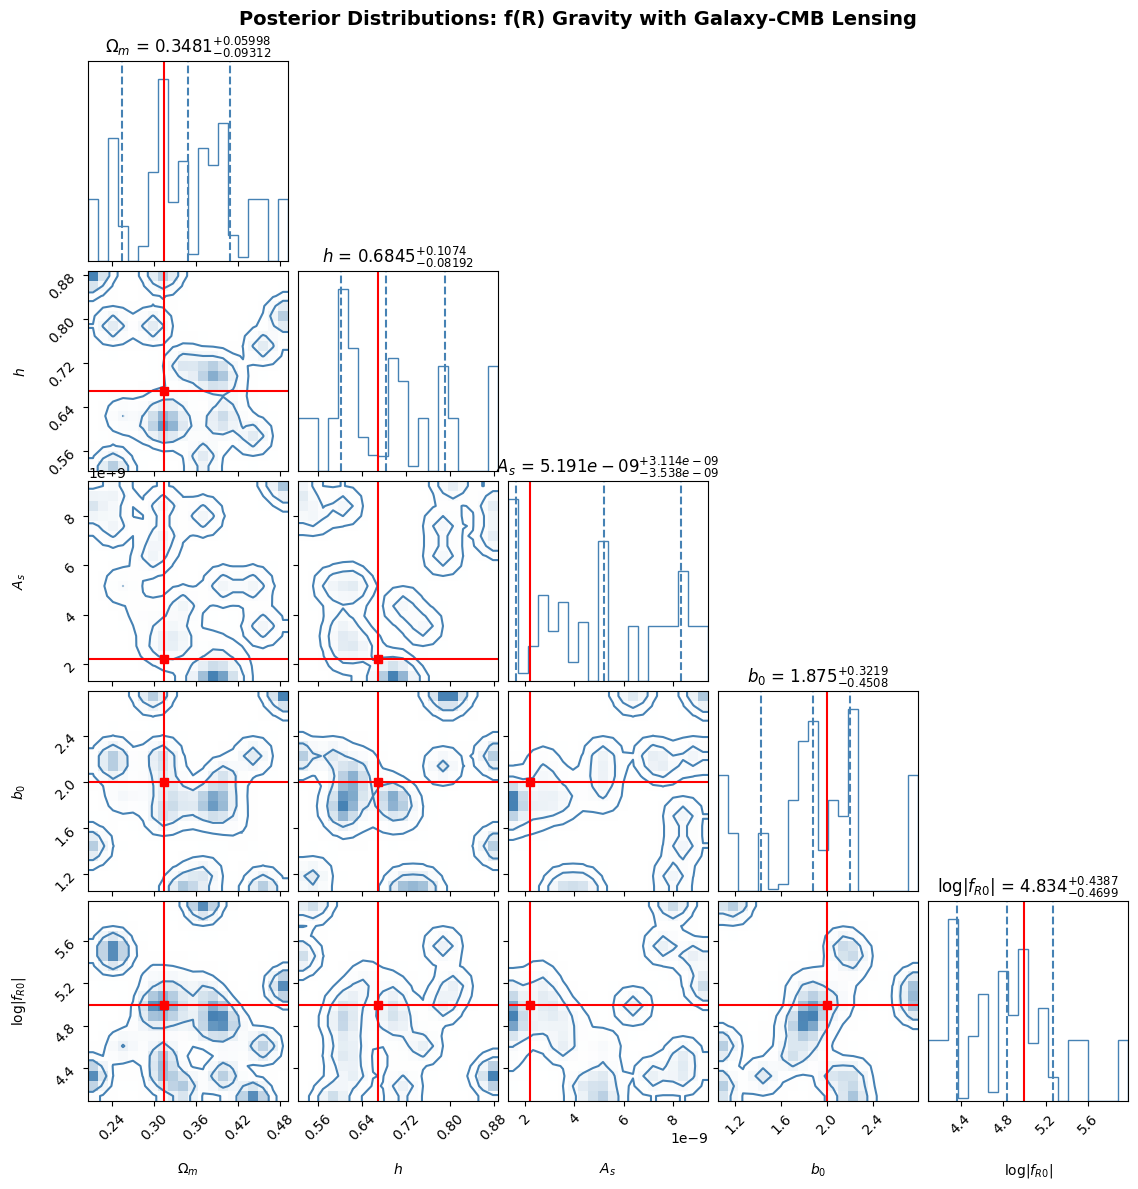


Generating chain convergence plot...
✓ Chain convergence plot saved: chain_convergence.png


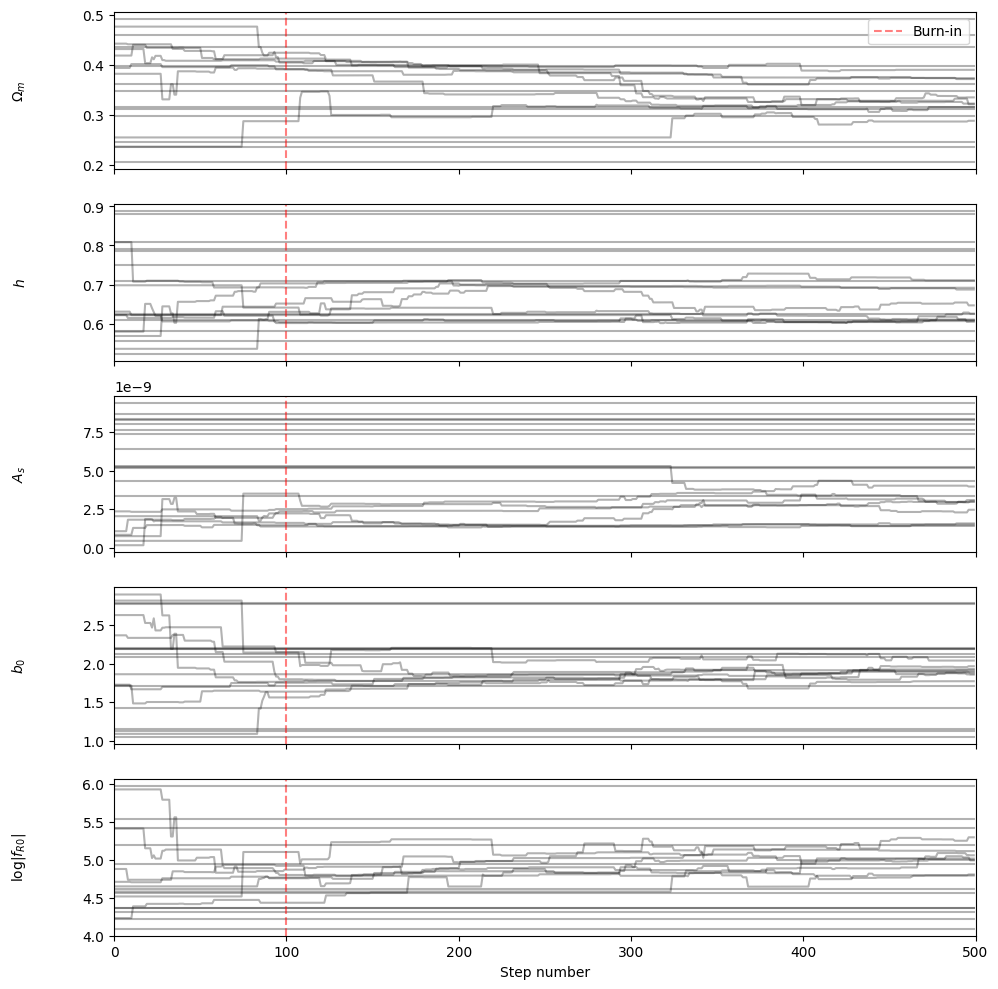


PARAMETER CONSTRAINTS (68% CL)

Parameter    Median       Lower        Upper        Truth       
------------------------------------------------------------
Omega_m      0.34814      0.25502      0.40812      0.315       
             0.34814 +0.059979 -0.093117
h            0.68446      0.60254      0.79184      0.67        
             0.68446 +0.10738 -0.081923
A_s          5.1909e-09   1.6526e-09   8.3045e-09   2.215e-09   
             5.1909e-09 +3.1136e-09 -3.5383e-09
b0           1.8754       1.4247       2.1973       2           
             1.8754 +0.32188 -0.45076
logfR0       4.8335       4.3636       5.2722       5           
             4.8335 +0.43865 -0.46986

n_s (fixed)  0.96         --           --           0.96        

SAVING RESULTS
✓ Results saved to: mcmc_results.npz

ANALYSIS COMPLETE


In [34]:
# ======================================================== 
# Run MCMC
# ========================================================
print("\n" + "="*60)
print("RUNNING MCMC SAMPLING")
print("="*60)
print("This may take several minutes...")
print("Progress will be shown below:")

try:
    # Run MCMC with progress bar
    state = sampler.run_mcmc(pos, nsteps, progress=True)
    
    print("\n✓ MCMC completed")
    
    # Get the chain
    samples_raw = sampler.get_chain()
    log_prob = sampler.get_log_prob()
    
    print(f"\nRaw chain shape: {samples_raw.shape}")
    print(f"  (steps, walkers, parameters) = {samples_raw.shape}")
    
    # Discard burn-in and flatten
    samples = sampler.get_chain(discard=burn_in, flat=True)
    log_prob_samples = sampler.get_log_prob(discard=burn_in, flat=True)
    
    print(f"\nAfter burn-in ({burn_in} steps):")
    print(f"  Samples shape: {samples.shape}")
    print(f"  Total samples: {len(samples)}")
    
    # Compute acceptance fraction
    acc_frac = np.mean(sampler.acceptance_fraction)
    print(f"\nAcceptance fraction: {acc_frac:.3f}")
    
    # Compute autocorrelation time
    try:
        tau = sampler.get_autocorr_time()
        print(f"Autocorrelation time:")
        for i, name in enumerate(param_names):
            print(f"  {name}: {tau[i]:.1f} steps")
    except Exception:
        print("Autocorrelation time: Could not compute (chain may be too short)")
    
    print(f"\nLog-probability statistics:")
    print(f"  Mean: {np.mean(log_prob_samples):.2f}")
    print(f"  Std: {np.std(log_prob_samples):.2f}")
    print(f"  Max: {np.max(log_prob_samples):.2f}")
    print(f"  Min: {np.min(log_prob_samples):.2f}")
    
    # Find best-fit parameters
    best_idx = np.argmax(log_prob_samples)
    best_params = samples[best_idx]
    best_logp = log_prob_samples[best_idx]
    
    print(f"\nBest-fit parameters (max log-probability):")
    print(f"  Log-probability: {best_logp:.2f}")
    for i, (name, value) in enumerate(zip(param_names, best_params)):
        print(f"  {name:10s} = {value:.6g}")
    
    # ========================================================
    # Corner Plot
    # ========================================================
    print("\n" + "="*60)
    print("GENERATING CORNER PLOT")
    print("="*60)
    
    param_labels = [r'$\Omega_m$', r'$h$', r'$A_s$', r'$b_0$', r'$\log|f_{R0}|$']

    truth_values = [
        fiducial_params['Omega_m'],
        fiducial_params['h'],
        fiducial_params['A_s'],
        fiducial_params['b0'],
        fiducial_params['logfR0']
    ]
    
    fig = corner.corner(
        samples,
        labels=param_labels,
        truths=truth_values,
        show_titles=True,
        quantiles=[0.16, 0.5, 0.84],
        title_fmt='.4g',
        smooth=1.0,
        color='steelblue',
        truth_color='red',
        levels=(0.68, 0.95)
    )
    
    fig.suptitle(
        r'Posterior Distributions: f(R) Gravity with Galaxy-CMB Lensing',
        fontsize=14,
        y=1.01,
        fontweight='bold'
    )
    
    plt.savefig('corner_plot.png', dpi=300, bbox_inches='tight')
    print("✓ Corner plot saved: corner_plot.png")
    plt.show()
    
    # ========================================================
    # Chain Convergence Plot
    # ========================================================
    print("\nGenerating chain convergence plot...")
    
    fig, axes = plt.subplots(ndim, figsize=(10, 10), sharex=True)
    samples_raw = sampler.get_chain()
    
    for i in range(ndim):
        ax = axes[i]
        ax.plot(samples_raw[:, :, i], "k", alpha=0.3)
        ax.set_xlim(0, len(samples_raw))
        ax.set_ylabel(param_labels[i])
        ax.axvline(burn_in, color='r', linestyle='--', alpha=0.5, label='Burn-in' if i == 0 else '')
        ax.yaxis.set_label_coords(-0.1, 0.5)
    
    axes[-1].set_xlabel("Step number")
    axes[0].legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('chain_convergence.png', dpi=300, bbox_inches='tight')
    print("✓ Chain convergence plot saved: chain_convergence.png")
    plt.show()
    
    # ========================================================
    # Print Parameter Constraints
    # ========================================================
    print("\n" + "="*60)
    print("PARAMETER CONSTRAINTS (68% CL)")
    print("="*60)
    
    print(f"\n{'Parameter':<12} {'Median':<12} {'Lower':<12} {'Upper':<12} {'Truth':<12}")
    print("-"*60)
    
    for i, name in enumerate(param_names):
        param_samples = samples[:, i]
        
        median = np.percentile(param_samples, 50)
        lower = np.percentile(param_samples, 16)
        upper = np.percentile(param_samples, 84)
        
        print(f"{name:<12} {median:<12.5g} {lower:<12.5g} {upper:<12.5g} {truth_values[i]:<12.5g}")
        print(f"{'':12} {median:.5g} +{upper-median:.5g} -{median-lower:.5g}")
    
    print(f"\n{'n_s (fixed)':<12} {fiducial_params['n_s']:<12.5g} {'--':<12} {'--':<12} {fiducial_params['n_s']:<12.5g}")
    
    # ========================================================
    # Save Results
    # ========================================================
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    results = {
        'samples': samples,
        'log_prob': log_prob_samples,
        'param_names': param_names,
        'best_params': best_params,
        'best_logp': best_logp,
        'acceptance_fraction': acc_frac,
        'fiducial_params': fiducial_params,
        'truth_values': truth_values,
        'nwalkers': nwalkers,
        'nsteps': nsteps,
        'burn_in': burn_in
    }
    
    np.savez('mcmc_results.npz', **results)
    print("✓ Results saved to: mcmc_results.npz")
    
except Exception as e:
    print(f"\n✗ Error during MCMC: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)